In [63]:
!python -m pip install numpy pandas \
    qiskit-aer qiskit-algorithms qiskit-machine-learning qiskit-ibm-runtime \
    pylatexenc ucimlrepo \
    xgboost catboost seaborn libsvm-official \
    jinja2 \
    scikit-optimize


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [64]:
import sys
import os

cwd = os.path.abspath(os.getcwd())
project_root = cwd.split("codes")[0] + "codes"

sys.path.append(os.path.abspath(project_root))

from utils.prepare_data import prepare_data

In [65]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [66]:
import warnings
from qiskit.transpiler import generate_preset_pass_manager
warnings.filterwarnings('ignore')

In [67]:
import sys
import importlib

def reload_package(package_name):
    modules_to_reload = [
        name for name in sys.modules
        if name.startswith(package_name)
    ]

    for name in sorted(modules_to_reload, reverse=True):
        importlib.reload(sys.modules[name])

# Usage
reload_package("model")
reload_package("utils")

In [68]:
dataset_path = os.path.join(project_root, "dataset", "Dataset_TehHijau.csv")
feature_cols = [
        "MQ3", 
        "TGS822", 
        "TGS2602", 
        "MQ5", 
        "MQ138", 
        "TGS2620", 
        "TGS813", 
        "TGS2600", 
        "TGS2611", 
        "TGS2603",
        "Humidity",
        "Celsius",
    ]
target_cols = "Kategori"

quantum_kernel_types = [
    # 'full', 
    'linear', 
    # 'circular', 
    # 'pauli_x', 
    # 'pauli_y', 
    # 'pauli_z'
]
kernel_types = [
    'linear', 
    # 'poly', 
    # 'rbf', 
    # 'sigmoid'
]

In [69]:
import pandas as pd
data = pd.read_csv(dataset_path)
data.head(10)

,MQ3,TGS822,TGS2602,MQ5,MQ138,TGS2620,TGS813,TGS2600,TGS2611,TGS2603,Humidity,Celsius,Chop_ID,Sampling_ID,Aroma,Taste,Color,Appearance,Dreg,Kategori,Standar Kualitas,MQ3_mean,MQ3_min,MQ3_max,MQ3_std,MQ3_skew,MQ3_kurtosis,MQ3_auc,TGS822_mean,TGS822_min,TGS822_max,TGS822_std,TGS822_skew,TGS822_kurtosis,TGS822_auc,TGS2602_mean,TGS2602_min,TGS2602_max,TGS2602_std,TGS2602_skew,TGS2602_kurtosis,TGS2602_auc,MQ5_mean,MQ5_min,MQ5_max,MQ5_std,MQ5_skew,MQ5_kurtosis,MQ5_auc,MQ138_mean,MQ138_min,MQ138_max,MQ138_std,MQ138_skew,MQ138_kurtosis,MQ138_auc,TGS2620_mean,TGS2620_min,TGS2620_max,TGS2620_std,TGS2620_skew,TGS2620_kurtosis,TGS2620_auc,TGS813_mean,TGS813_min,TGS813_max,TGS813_std,TGS813_skew,TGS813_kurtosis,TGS813_auc,TGS2600_mean,TGS2600_min,TGS2600_max,TGS2600_std,TGS2600_skew,TGS2600_kurtosis,TGS2600_auc,TGS2611_mean,TGS2611_min,TGS2611_max,TGS2611_std,TGS2611_skew,TGS2611_kurtosis,TGS2611_auc,TGS2603_mean,TGS2603_min,TGS2603_max,TGS2603_std,TGS2603_skew,TGS2603_kurtosis,TGS2603_auc,Humidity_mean,Humidity_min,Humidity_max,Humidity_std,Humidity_skew,Humidity_kurtosis,Humidity_auc,Celsius_mean,Celsius_min,Celsius_max,Celsius_std,Celsius_skew,Celsius_kurtosis,Celsius_auc,Aroma_mean,Aroma_min,Aroma_max,Aroma_std,Aroma_auc,Taste_mean,Taste_min,Taste_max,Taste_std,Taste_auc,Color_mean,Color_min,Color_max,Color_std,Color_auc,Appearance_mean,Appearance_min,Appearance_max,Appearance_std,Appearance_auc,Dreg_mean,Dreg_min,Dreg_max,Dreg_std,Dreg_auc
0,90.0000,43.0000,46.0000,133.0000,97.0000,46.0000,552.0000,289.0000,546.0000,371.0000,46.4000,38.9000,TR612,TR612_1,2.9000,36,3.2000,2.8000,3.2000,D,Baik,89.7000,89.0000,90,0.4830,-0.8729,-1.2381,807.0000,41.9000,41,43,0.7379,0.1399,-0.9604,377.0000,46.8000,46,48,0.7888,0.3436,-1.1531,421.0000,132.5000,132,133.0000,0.5270,0.0000,-2.0000,1192.5000,96.1000,95,97,0.7379,-0.1399,-0.9604,865.0000,45.7000,45,47,0.6749,0.3657,-0.7055,411.0000,551.6000,550,553,0.8433,-0.3281,-0.3359,4964.5000,289.8000,289.0000,291,0.7888,0.3436,-1.1531,2609.0000,546.5000,545,548,0.8498,0.0000,-0.4852,4918.5000,370.2000,369,371,0.7888,-0.3436,-1.1531,3331.0000,46.4300,46.3000,46.5000,0.0675,-0.3657,-0.7055,417.9500,38.8100,38.7000,38.9000,0.0876,-0.1884,-1.5261,349.3000,2.9000,2.9000,2.9000,0.0000,26.1000,36,36,36,0,324,3.2000,3.2000,3.2000,0.0000,28.8000,2.8000,2.8000,2.8000,0.0000,25.2000,3.2000,3.2000,3.2000,0.0000,28.8000
1,90.0000,42.0000,47.0000,133.0000,96.0000,47.0000,551.0000,290.0000,547.0000,371.0000,46.5000,38.9000,TR612,TR612_1,2.9000,36,3.2000,2.8000,3.2000,D,Baik,89.7000,89.0000,90,0.4830,-0.8729,-1.2381,807.0000,41.9000,41,43,0.7379,0.1399,-0.9604,377.0000,46.8000,46,48,0.7888,0.3436,-1.1531,421.0000,132.5000,132,133.0000,0.5270,0.0000,-2.0000,1192.5000,96.1000,95,97,0.7379,-0.1399,-0.9604,865.0000,45.7000,45,47,0.6749,0.3657,-0.7055,411.0000,551.6000,550,553,0.8433,-0.3281,-0.3359,4964.5000,289.8000,289.0000,291,0.7888,0.3436,-1.1531,2609.0000,546.5000,545,548,0.8498,0.0000,-0.4852,4918.5000,370.2000,369,371,0.7888,-0.3436,-1.1531,3331.0000,46.4300,46.3000,46.5000,0.0675,-0.3657,-0.7055,417.9500,38.8100,38.7000,38.9000,0.0876,-0.1884,-1.5261,349.3000,2.9000,2.9000,2.9000,0.0000,26.1000,36,36,36,0,324,3.2000,3.2000,3.2000,0.0000,28.8000,2.8000,2.8000,2.8000,0.0000,25.2000,3.2000,3.2000,3.2000,0.0000,28.8000
2,89.0000,42.0000,47.0000,133.0000,97.0000,45.0000,553.0000,291.0000,547.0000,369.0000,46.4000,38.9000,TR612,TR612_1,2.9000,36,3.2000,2.8000,3.2000,D,Baik,89.7000,89.0000,90,0.4830,-0.8729,-1.2381,807.0000,41.9000,41,43,0.7379,0.1399,-0.9604,377.0000,46.8000,46,48,0.7888,0.3436,-1.1531,421.0000,132.5000,132,133.0000,0.5270,0.0000,-2.0000,1192.5000,96.1000,95,97,0.7379,-0.1399,-0.9604,865.0000,45.7000,45,47,0.6749,0.3657,-0.7055,411.0000,551.6000,550,553,0.8433,-0.3281,-0.3359,4964.5000,289.8000,289.0000,291,0.7888,0.3436,-1.1531,2609.0000,546.5000,545,548,0.8498,0.0000,-0.4852,4918.5000,370.2000,369,371,0.7888,-0.3436,-1.1531,3331.0000,46.4300,46.3000,46.5000,0.0675,-0.3657,-0.7055,417.9500,38.8100,38.700

In [70]:
data.describe()

,MQ3,TGS822,TGS2602,MQ5,MQ138,TGS2620,TGS813,TGS2600,TGS2611,TGS2603,Humidity,Celsius,Aroma,Taste,Color,Appearance,Dreg,MQ3_mean,MQ3_min,MQ3_max,MQ3_std,MQ3_skew,MQ3_kurtosis,MQ3_auc,TGS822_mean,TGS822_min,TGS822_max,TGS822_std,TGS822_skew,TGS822_kurtosis,TGS822_auc,TGS2602_mean,TGS2602_min,TGS2602_max,TGS2602_std,TGS2602_skew,TGS2602_kurtosis,TGS2602_auc,MQ5_mean,MQ5_min,MQ5_max,MQ5_std,MQ5_skew,MQ5_kurtosis,MQ5_auc,MQ138_mean,MQ138_min,MQ138_max,MQ138_std,MQ138_skew,MQ138_kurtosis,MQ138_auc,TGS2620_mean,TGS2620_min,TGS2620_max,TGS2620_std,TGS2620_skew,TGS2620_kurtosis,TGS2620_auc,TGS813_mean,TGS813_min,TGS813_max,TGS813_std,TGS813_skew,TGS813_kurtosis,TGS813_auc,TGS2600_mean,TGS2600_min,TGS2600_max,TGS2600_std,TGS2600_skew,TGS2600_kurtosis,TGS2600_auc,TGS2611_mean,TGS2611_min,TGS2611_max,TGS2611_std,TGS2611_skew,TGS2611_kurtosis,TGS2611_auc,TGS2603_mean,TGS2603_min,TGS2603_max,TGS2603_std,TGS2603_skew,TGS2603_kurtosis,TGS2603_auc,Humidity_mean,Humidity_min,Humidity_max,Humidity_std,Humidity_skew,Humidity_kurtosis,Humidity_auc,Celsius_mean,Celsius_min,Celsius_max,Celsius_std,Celsius_skew,Celsius_kurtosis,Celsius_auc,Aroma_mean,Aroma_min,Aroma_max,Aroma_std,Aroma_auc,Taste_mean,Taste_min,Taste_max,Taste_std,Taste_auc,Color_mean,Color_min,Color_max,Color_std,Color_auc,Appearance_mean,Appearance_min,Appearance_max,Appearance_std,Appearance_auc,Dreg_mean,Dreg_min,Dreg_max,Dreg_std,Dreg_auc
count,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000
mean,89.4148,47.6007,47.9362,98.2916,89.1822,51.5488,533.6701,213.7386,531.1246,330.5003,48.3877,39.6567,2.9351,34.8889,3.0354,3.1353,3.0719,89.4012,88.0726,90.8381,0.9831,0.0311,-0.4979,797.2830,51.3814,46.4283,86.3774,12.7680,0.0479,-0.7677,461.0916,48.9235,46.6657,56.4011,3.4174,0.0421,-0.7428,435.5016,98.3196,97.1902,99.9750,0.9774,0.1539,-0.3362,872.0037,89.1671,87.8391,90.5666,0.9752,0.0541,-0.7782,790.1031,52.0472,50.2007,56.9313,2.4119,0.0111,-0.7795,460.3774,533.5854,530.4756,535.6482,1.7161,-0.2305,-0.6140,4754.9384,215.5427,212.0394,231.5642,6.5498,-0.0593,-0.6575,1919.9904,531.0398,529.3107,532.0894,1.0005,-0.0311,-0.8901,4742.8424,330.4472,328.8314,331.6405,0.9806,0.0223,-0.7770,2953.2800,4077.8091,48.1753,40342.7838,12742.2929,-0.0207,-0.4484,40727.0018,39.6562,39.5960,39.7184,0.0507,-0.0031,0.0236,355.6654,2.9351,2.9351,2.9351,0.0000,26.4163,34.8889,34.8889,34.8889,0.0000,314.0005,3.0354,3.0354,3.0354,0.0000,27.3184,3.1353,3.1353,3.1353,0.0000,28.2178,3.0719,3.0719,3.0719,0.0000,27.6469
std,3.6692,4.6781,4.6166,15.8494,4.2090,4.9676,7.0074,24.6137,5.5522,12.9071,3.1265,1.3128,0.2578,1.7327,0.2553,0.2705,0.3078,4.2821,7.6516,21.2644,7.0327,0.8407,1.5014,52.9311,134.

Text(0.5, 1.0, 'Histogram for the Kategori')

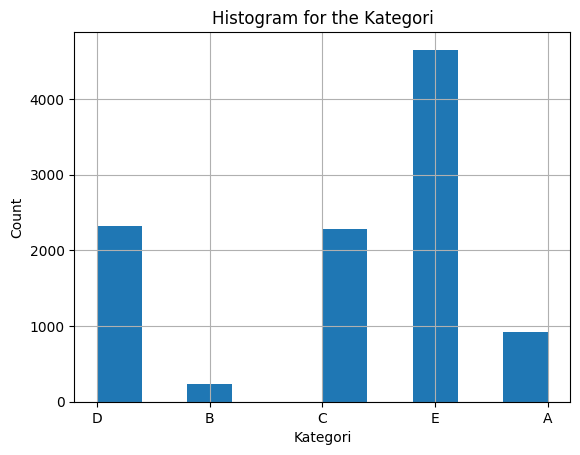

In [71]:
import matplotlib.pyplot as plt
data['Kategori'].hist()
plt.xlabel('Kategori')
plt.ylabel('Count')
plt.title('Histogram for the Kategori')

In [72]:
X = data[feature_cols]
y = data[target_cols]

print(X.shape, y.shape)

(10409, 12) (10409,)


In [73]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [74]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
def plot_pca_variance(X, n_components, threshold=0.95):
  pca = PCA(n_components=n_components)
  pca.fit(X)

  cumvar = np.cumsum(pca.explained_variance_ratio_)
  n_optimal = np.argmax(cumvar >= threshold) + 1

  plt.figure(figsize=(8, 5))
  plt.plot(range(1, n_components + 1), cumvar, marker='o', color='blue')
  plt.axhline(y=threshold, color='gray', linestyle='--', linewidth=1)
  plt.xlabel('Number of Principal Components')
  plt.ylabel('Cumulative Explained Variance')
  plt.xticks(range(1, n_components + 1))
  plt.grid(True)
  plt.tight_layout()
  plt.show()

  print(f'Optimal number of components to retain {threshold*100:.0f}% variance: {n_optimal}')

  return n_optimal

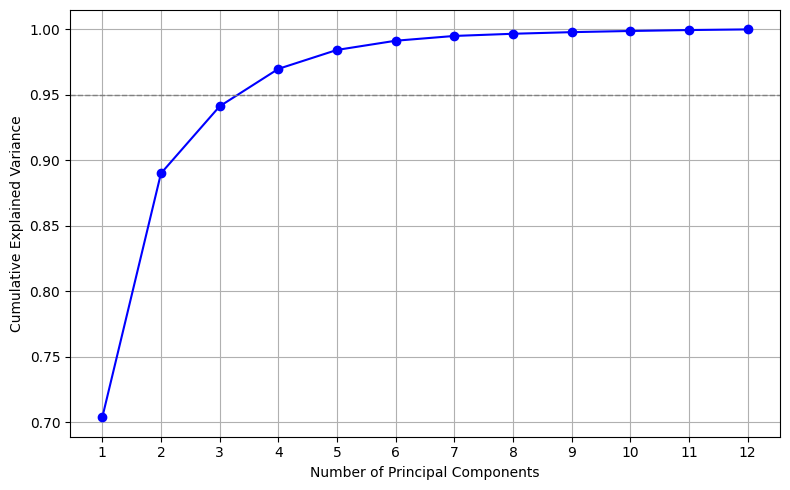

Optimal number of components to retain 95% variance: 4


In [75]:
n_optimal = plot_pca_variance(X, n_components=X.shape[1], threshold=0.95)

In [76]:
import time
from pathlib import Path
from datetime import datetime

all_best = []  # collects best_result from every model
_iter_t0 = None

# Logger setup
log_dir = Path("./results/logs/ml/best_param")
log_dir.mkdir(parents=True, exist_ok=True)

_current_log_path = None

def setup_logger(name):
  """Panggil di awal tiap section. name contoh: 'svc_linear', 'xgb_gbtree'."""
  global _current_log_path
  _current_log_path = log_dir / f"classical_{name}_hpo.log"
  # truncate file kalau sudah ada, biar tiap run fresh
  _current_log_path.write_text("")
  log(f"📝 Log: {_current_log_path}")
  log(f"🕒 Started: {datetime.now().isoformat(timespec='seconds')}")

def log(msg=""):
  """Print ke console dan append ke file log section aktif."""
  print(msg)
  if _current_log_path is not None:
    with open(_current_log_path, "a", encoding="utf-8") as f:
      f.write(str(msg) + "\n")


# 1. SVC

## 1.1 Linear

In [77]:
# Search Space Configuration
import numpy as np

search_space = {
  'C': [10],
  'tol': [0.1]
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [78]:
setup_logger("svc_linear")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from utils.hpo import get_search_space
from skopt import BayesSearchCV
from sklearn.decomposition import PCA
from model.models import svc_model
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

best_score = -np.inf
best_result = None
results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())
  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()
  

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('svc', SVC(class_weight='balanced',
        kernel='linear',
        probability=True,
        random_state=42, 
        decision_function_shape='ovr',
        **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'y_true': list(y_val_all),
        'y_pred': list(y_pred_all),
        'execution_time': iter_time,
    }

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']:.4f} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

📝 Log: results\logs\ml\best_param\classical_svc_linear_hpo.log
🕒 Started: 2026-06-06T04:07:05
🔬 Search space: 1 C × 1 tol =  1 configs × 5 folds = 5 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/1] C=10 | tol=0.1
    F1 → Acc=0.3934 | Prec=0.5784 | Rec=0.3934 | F1=0.4058 | AUROC=0.6947 | PRAUC=0.4846
    F2 → Acc=0.4025 | Prec=0.5790 | Rec=0.4025 | F1=0.4163 | AUROC=0.7087 | PRAUC=0.4999
    F3 → Acc=0.3838 | Prec=0.5537 | Rec=0.3838 | F1=0.3918 | AUROC=0.6798 | PRAUC=0.4719
    F4 → Acc=0.4049 | Prec=0.5599 | Rec=0.4049 | F1=0.4117 | AUROC=0.6925 | PRAUC=0.4837
    F5 → Acc=0.3767 | Prec=0.5466 | Rec=0.3767 | F1=0.3835 | AUROC=0.6853 | PRAUC=0.4723
  ✅  Acc:0.3923±0.0108 | Precision:0.5635±0.0131  |Recall:0.3923±0.0108 |F1:0.4018±0.0123 | AUROC:0.6922±0.0098 | PRAUC:0.4825±0.0103 | MCC:0.2574 | Composite:0.5223

🏆 Best config : C=10 | tol=0.1
   Composite   : 0.5223 (AUROC=0.6922±0.0098 | PRAUC=0.4825±0.0103 | Acc=0.3923±0.0108 |Prec=0.5635±0.0131 |Rec=0.3923±0.010

In [79]:
import pandas as pd
import os

dirpath = "./results/best_param/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + "svc_linear_hpo.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

✅ Saved: ./results/best_param/svc_linear_hpo.csv


In [80]:
# ── Collect best result ──
best_result['model'] = "SVC Linear"
all_best.append(dict(best_result))
log(f"✅ [SVC Linear] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [SVC Linear] recorded | Exec. time: 238.8s


## 1.2 Poly

In [81]:
# Search Space Configuration
import numpy as np

search_space = {
  'C': [1],
  'tol': [0.1],
  'degree': [5],
  'gamma': [0.5],
  'coef0': [3],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [82]:
setup_logger("svc_poly")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from utils.hpo import get_search_space
from skopt import BayesSearchCV
from sklearn.decomposition import PCA
from model.models import svc_model
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

best_score = -np.inf
best_result = None
results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())
  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()
  
  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('svc', SVC(class_weight='balanced',kernel='poly', probability=True, random_state=42, **params))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

     
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'y_true': list(y_val_all),
        'y_pred': list(y_pred_all),
        'execution_time': iter_time,
    }

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']:.4f} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

📝 Log: results\logs\ml\best_param\classical_svc_poly_hpo.log
🕒 Started: 2026-06-06T04:11:04
🔬 Search space: 1 C × 1 tol × 1 degree × 1 gamma × 1 coef0 =  1 configs × 5 folds = 5 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/1] C=1 | tol=0.1 | degree=5 | gamma=0.5 | coef0=3
    F1 → Acc=0.9693 | Prec=0.9708 | Rec=0.9693 | F1=0.9696 | AUROC=0.9987 | PRAUC=0.9958
    F2 → Acc=0.9726 | Prec=0.9732 | Rec=0.9726 | F1=0.9727 | AUROC=0.9982 | PRAUC=0.9951
    F3 → Acc=0.9664 | Prec=0.9680 | Rec=0.9664 | F1=0.9667 | AUROC=0.9976 | PRAUC=0.9938
    F4 → Acc=0.9721 | Prec=0.9733 | Rec=0.9721 | F1=0.9724 | AUROC=0.9988 | PRAUC=0.9962
    F5 → Acc=0.9635 | Prec=0.9651 | Rec=0.9635 | F1=0.9637 | AUROC=0.9981 | PRAUC=0.9935
  ✅  Acc:0.9688±0.0035 | Precision:0.9701±0.0032  |Recall:0.9688±0.0035 |F1:0.9691±0.0034 | AUROC:0.9983±0.0004 | PRAUC:0.9949±0.0011 | MCC:0.9555 | Composite:0.9873

🏆 Best config : C=1 | tol=0.1 | degree=5 | gamma=0.5 | coef0=3
   Composite   : 0.9873 (AUROC=

In [83]:
import pandas as pd
import os

dirpath = "./results/best_param/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + "svc_poly_hpo.csv"
df.to_csv(filename, index=False)

print(f"✅ Saved: {filename}")

✅ Saved: ./results/best_param/svc_poly_hpo.csv


In [84]:
# ── Collect best result ──
best_result['model'] = "SVC Poly"
all_best.append(dict(best_result))
log(f"✅ [SVC Poly] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [SVC Poly] recorded | Exec. time: 88.2s


## 1.3 RBF

In [85]:
# Search Space Configuration
import numpy as np

search_space = {
  'C': [10],
  'tol': [0.1],
  'gamma': [0.5],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [86]:
setup_logger("svc_rbf")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from utils.hpo import get_search_space
from skopt import BayesSearchCV
from sklearn.decomposition import PCA
from model.models import svc_model
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

best_score = -np.inf
best_result = None
results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())
  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()
  
  
  log(f"\n  ▶ {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('svc', SVC(class_weight='balanced', decision_function_shape='ovr', kernel='rbf', probability=True, random_state=42, **params))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

     
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'y_true': list(y_val_all),
        'y_pred': list(y_pred_all),
        'execution_time': iter_time,
    }

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']:.4f} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

📝 Log: results\logs\ml\best_param\classical_svc_rbf_hpo.log
🕒 Started: 2026-06-06T04:12:32
🔬 Search space: 1 C × 1 tol × 1 gamma =  1 configs × 5 folds = 5 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/1] C=10 | tol=0.1 | gamma=0.5

  ▶ C=10 | tol=0.1 | gamma=0.5
    F1 → Acc=0.9726 | Prec=0.9740 | Rec=0.9726 | F1=0.9729 | AUROC=0.9991 | PRAUC=0.9968
    F2 → Acc=0.9745 | Prec=0.9753 | Rec=0.9745 | F1=0.9747 | AUROC=0.9975 | PRAUC=0.9895
    F3 → Acc=0.9721 | Prec=0.9736 | Rec=0.9721 | F1=0.9725 | AUROC=0.9976 | PRAUC=0.9928
    F4 → Acc=0.9765 | Prec=0.9773 | Rec=0.9765 | F1=0.9767 | AUROC=0.9990 | PRAUC=0.9965
    F5 → Acc=0.9649 | Prec=0.9666 | Rec=0.9649 | F1=0.9653 | AUROC=0.9981 | PRAUC=0.9935
  ✅  Acc:0.9721±0.0039 | Precision:0.9733±0.0036  |Recall:0.9721±0.0039 |F1:0.9724±0.0038 | AUROC:0.9983±0.0007 | PRAUC:0.9938±0.0027 | MCC:0.9603 | Composite:0.9881

🏆 Best config : C=10 | tol=0.1 | gamma=0.5
   Composite   : 0.9881 (AUROC=0.9983±0.0007 | PRAUC=0.9938±0

In [87]:
import pandas as pd
import os

dirpath = "./results/best_param/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + "svc_rbf_hpo.csv"
df.to_csv(filename, index=False)

print(f"✅ Saved: {filename}")

✅ Saved: ./results/best_param/svc_rbf_hpo.csv


In [88]:
# ── Collect best result ──
best_result['model'] = "SVC RBF"
all_best.append(dict(best_result))
log(f"✅ [SVC RBF] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [SVC RBF] recorded | Exec. time: 13.2s


## 1.4 Sigmoid

In [89]:
# Search Space Configuration
import numpy as np

search_space = {
  'C': [1],
  'tol': [0.1],
  'gamma': [0.01],
  'coef0': [0],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [90]:
setup_logger("svc_sigmoid")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from utils.hpo import get_search_space
from skopt import BayesSearchCV
from sklearn.decomposition import PCA
from model.models import svc_model
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

best_score = -np.inf
best_result = None
results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())
  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()
  
  
  log(f"\n  ▶ {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('svc', SVC(decision_function_shape='ovr', class_weight='balanced',kernel='sigmoid', probability=True, random_state=42, **params))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

     
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'y_true': list(y_val_all),
        'y_pred': list(y_pred_all),
        'execution_time': iter_time,
    }

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']:.4f} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

📝 Log: results\logs\ml\best_param\classical_svc_sigmoid_hpo.log
🕒 Started: 2026-06-06T04:12:45
🔬 Search space: 1 C × 1 tol × 1 gamma × 1 coef0 =  1 configs × 5 folds = 5 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/1] C=1 | tol=0.1 | gamma=0.01 | coef0=0

  ▶ C=1 | tol=0.1 | gamma=0.01 | coef0=0
    F1 → Acc=0.3497 | Prec=0.5191 | Rec=0.3497 | F1=0.3541 | AUROC=0.6785 | PRAUC=0.4542
    F2 → Acc=0.3598 | Prec=0.5453 | Rec=0.3598 | F1=0.3712 | AUROC=0.6922 | PRAUC=0.4695
    F3 → Acc=0.3463 | Prec=0.5239 | Rec=0.3463 | F1=0.3522 | AUROC=0.6632 | PRAUC=0.4432
    F4 → Acc=0.3871 | Prec=0.5411 | Rec=0.3871 | F1=0.3851 | AUROC=0.6791 | PRAUC=0.4595
    F5 → Acc=0.3489 | Prec=0.5132 | Rec=0.3489 | F1=0.3498 | AUROC=0.6699 | PRAUC=0.4439
  ✅  Acc:0.3583±0.0151 | Precision:0.5285±0.0125  |Recall:0.3583±0.0151 |F1:0.3625±0.0136 | AUROC:0.6766±0.0098 | PRAUC:0.4541±0.0099 | MCC:0.2135 | Composite:0.4963

🏆 Best config : C=1 | tol=0.1 | gamma=0.01 | coef0=0
   Composite   : 

In [91]:
import pandas as pd
import os

dirpath = "./results/best_param/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + "svc_rbf_hpo.csv"
df.to_csv(filename, index=False)

print(f"✅ Saved: {filename}")

✅ Saved: ./results/best_param/svc_rbf_hpo.csv


In [92]:
# ── Collect best result ──
best_result['model'] = "SVC Sigmoid"
all_best.append(dict(best_result))
log(f"✅ [SVC Sigmoid] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [SVC Sigmoid] recorded | Exec. time: 118.9s


# 2. XGBoost

## 2.1 GBTree

In [93]:
# Search Space Configuration
import numpy as np

# search_space = {
#   'n_estimators': [1000],
#   'learning_rate': [0.01],
#   'max_depth': [10],
#   'subsample': [0.5],
#   'colsample_bytree': [1],
# }

search_space = {
  'n_estimators': [100],
  'learning_rate': [0.1],
  'max_depth': [10],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [94]:
setup_logger("xgb_gbtree")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_sample_weight  # ← imbalance handling
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

best_score = -np.inf
best_result = None
results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())
  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()
  
  
  log(f"\n  ▶ {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('xgb', XGBClassifier(
        booster='gbtree', objective='multi:softprob', random_state=42, device='cuda', **params
      ))
    ])

    # Per-fold balanced sample_weight (XGBoost tidak punya class_weight)
    sw_train = compute_sample_weight('balanced', y_train)
    model.fit(X_train, y_train, xgb__sample_weight=sw_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'y_true': list(y_val_all),
        'y_pred': list(y_pred_all),
        'execution_time': iter_time,
    }

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']:.4f} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

📝 Log: results\logs\ml\best_param\classical_xgb_gbtree_hpo.log
🕒 Started: 2026-06-06T04:14:44
🔬 Search space: 1 n_estimators × 1 learning_rate × 1 max_depth =  1 configs × 5 folds = 5 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/1] n_estimators=100 | learning_rate=0.1 | max_depth=10

  ▶ n_estimators=100 | learning_rate=0.1 | max_depth=10
    F1 → Acc=0.9673 | Prec=0.9677 | Rec=0.9673 | F1=0.9674 | AUROC=0.9989 | PRAUC=0.9965
    F2 → Acc=0.9750 | Prec=0.9753 | Rec=0.9750 | F1=0.9751 | AUROC=0.9990 | PRAUC=0.9973
    F3 → Acc=0.9673 | Prec=0.9676 | Rec=0.9673 | F1=0.9674 | AUROC=0.9981 | PRAUC=0.9935
    F4 → Acc=0.9779 | Prec=0.9782 | Rec=0.9779 | F1=0.9780 | AUROC=0.9993 | PRAUC=0.9978
    F5 → Acc=0.9644 | Prec=0.9648 | Rec=0.9644 | F1=0.9645 | AUROC=0.9978 | PRAUC=0.9926
  ✅  Acc:0.9704±0.0051 | Precision:0.9707±0.0051  |Recall:0.9704±0.0051 |F1:0.9705±0.0051 | AUROC:0.9986±0.0006 | PRAUC:0.9955±0.0021 | MCC:0.9575 | Composite:0.9882

🏆 Best config : n_estimato

In [95]:
import pandas as pd
import os

dirpath = "./results/best_param/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + "xgb_gbtree_hpo.csv"
df.to_csv(filename, index=False)

print(f"✅ Saved: {filename}")

✅ Saved: ./results/best_param/xgb_gbtree_hpo.csv


In [96]:
# ── Collect best result ──
best_result['model'] = "XGBoost GBTree"
all_best.append(dict(best_result))
log(f"✅ [XGBoost GBTree] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [XGBoost GBTree] recorded | Exec. time: 36.3s


## 2.2 Dart

In [97]:
# Search Space Configuration
import numpy as np

# search_space = {
#   'n_estimators': [1000],
#   'learning_rate': [0.01],
#   'max_depth': [10],
#   'subsample': [0.5],
#   'colsample_bytree': [1],

#   'rate_drop': [0],
# }

search_space = {
  'n_estimators': [100],
  'learning_rate': [0.1],
  'max_depth': [10],
  'rate_drop': [0.1],
  'skip_drop': [0.5],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [98]:
setup_logger("xgb_dart")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_sample_weight  # ← imbalance handling
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

best_score = -np.inf
best_result = None
results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())
  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()
  
  
  log(f"\n  ▶ {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('xgb', XGBClassifier(
        booster='dart', objective='multi:softprob', random_state=42, device='cuda', **params
      ))
    ])

    # Per-fold balanced sample_weight (XGBoost tidak punya class_weight)
    sw_train = compute_sample_weight('balanced', y_train)
    model.fit(X_train, y_train, xgb__sample_weight=sw_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'y_true': list(y_val_all),
        'y_pred': list(y_pred_all),
        'execution_time': iter_time,
    }

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']:.4f} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

📝 Log: results\logs\ml\best_param\classical_xgb_dart_hpo.log
🕒 Started: 2026-06-06T04:15:21
🔬 Search space: 1 n_estimators × 1 learning_rate × 1 max_depth × 1 rate_drop × 1 skip_drop =  1 configs × 5 folds = 5 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/1] n_estimators=100 | learning_rate=0.1 | max_depth=10 | rate_drop=0.1 | skip_drop=0.5

  ▶ n_estimators=100 | learning_rate=0.1 | max_depth=10 | rate_drop=0.1 | skip_drop=0.5
    F1 → Acc=0.9640 | Prec=0.9644 | Rec=0.9640 | F1=0.9641 | AUROC=0.9987 | PRAUC=0.9959
    F2 → Acc=0.9702 | Prec=0.9708 | Rec=0.9702 | F1=0.9703 | AUROC=0.9989 | PRAUC=0.9969
    F3 → Acc=0.9621 | Prec=0.9629 | Rec=0.9621 | F1=0.9623 | AUROC=0.9976 | PRAUC=0.9921
    F4 → Acc=0.9779 | Prec=0.9783 | Rec=0.9779 | F1=0.9780 | AUROC=0.9992 | PRAUC=0.9975
    F5 → Acc=0.9620 | Prec=0.9625 | Rec=0.9620 | F1=0.9621 | AUROC=0.9971 | PRAUC=0.9906
  ✅  Acc:0.9672±0.0061 | Precision:0.9678±0.0060  |Recall:0.9672±0.0061 |F1:0.9674±0.0061 | AUROC:0.998

In [99]:
import pandas as pd
import os

dirpath = "./results/best_param/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + "xgb_dart_hpo.csv"
df.to_csv(filename, index=False)

print(f"✅ Saved: {filename}")

✅ Saved: ./results/best_param/xgb_dart_hpo.csv


In [100]:
# ── Collect best result ──
best_result['model'] = "XGBoost Dart"
all_best.append(dict(best_result))
log(f"✅ [XGBoost Dart] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [XGBoost Dart] recorded | Exec. time: 76.7s


# 3. CatBoost

In [101]:
# Search Space Configuration
import numpy as np

search_space = {
  'iterations': [500],
  'depth': [10],
  'learning_rate': [0.1],
  'l2_leaf_reg': [1],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [102]:
setup_logger("catboost")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)
from catboost import CatBoostClassifier

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

best_score = -np.inf
best_result = None
results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())
  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('cat', CatBoostClassifier(
        loss_function="MultiClassOneVsAll",
        eval_metric="Accuracy",
        verbose=0,
        random_seed=42, 
        task_type="GPU",
        devices='0',
        auto_class_weights='Balanced',  # ← imbalance handling
        **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)
    y_prob = y_prob / y_prob.sum(axis=1, keepdims=True)  # Normalize probabilities

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'y_true': list(y_val_all),
        'y_pred': list(y_pred_all),
        'execution_time': iter_time,
    }

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']:.4f} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

📝 Log: results\logs\ml\best_param\classical_catboost_hpo.log
🕒 Started: 2026-06-06T04:16:37
🔬 Search space: 1 iterations × 1 depth × 1 learning_rate × 1 l2_leaf_reg =  1 configs × 5 folds = 5 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/1] iterations=500 | depth=10 | learning_rate=0.1 | l2_leaf_reg=1


    F1 → Acc=0.9793 | Prec=0.9800 | Rec=0.9793 | F1=0.9795 | AUROC=0.9993 | PRAUC=0.9978
    F2 → Acc=0.9789 | Prec=0.9792 | Rec=0.9789 | F1=0.9789 | AUROC=0.9993 | PRAUC=0.9980
    F3 → Acc=0.9726 | Prec=0.9730 | Rec=0.9726 | F1=0.9728 | AUROC=0.9989 | PRAUC=0.9965
    F4 → Acc=0.9813 | Prec=0.9815 | Rec=0.9813 | F1=0.9813 | AUROC=0.9996 | PRAUC=0.9985
    F5 → Acc=0.9673 | Prec=0.9678 | Rec=0.9673 | F1=0.9674 | AUROC=0.9985 | PRAUC=0.9951
  ✅  Acc:0.9759±0.0052 | Precision:0.9763±0.0051  |Recall:0.9759±0.0052 |F1:0.9760±0.0052 | AUROC:0.9991±0.0004 | PRAUC:0.9972±0.0012 | MCC:0.9654 | Composite:0.9907

🏆 Best config : iterations=500 | depth=10 | learning_rate=0.1 | l2_leaf_reg=1
   Composite   : 0.9907 (AUROC=0.9991±0.0004 | PRAUC=0.9972±0.0012 | Acc=0.9759±0.0052 |Prec=0.9763±0.0051 |Rec=0.9759±0.0052) |


In [103]:
import pandas as pd
import os

dirpath = "./results/best_param/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + "catboost_hpo.csv"
df.to_csv(filename, index=False)

print(f"✅ Saved: {filename}")

✅ Saved: ./results/best_param/catboost_hpo.csv


In [104]:
# ── Collect best result ──
best_result['model'] = "CatBoost"
all_best.append(dict(best_result))
log(f"✅ [CatBoost] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [CatBoost] recorded | Exec. time: 189.0s


---
## 📊 Tabel Evaluasi Akhir

In [105]:
# ════════════════════════════════════════════════════════════
# 📊 TABEL EVALUASI AKHIR – Classical Models
# ════════════════════════════════════════════════════════════
import pandas as pd

def build_eval_table(all_best):
    rows = []
    for r in all_best:
        params_str = ' | '.join(f'{k}={v}' for k, v in r.get('params', {}).items())
        rows.append({
            'Model'          : r['model'],
            'Accuracy'       : r['acc'],
            'Precision'      : r['prec'],
            'Recall'         : r['rec'],
            'F1-Score'       : r['f1'],
            'ROC-AUC'        : r['roc'],
            'PR-AUC'         : r['pra'],
            'Exec. Time (s)' : round(r['execution_time'], 2) if 'execution_time' in r else 'N/A',
            'Best Params'    : params_str,
        })
    df = pd.DataFrame(rows)
    df = df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
    df.index += 1
    return df

pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.4f}'.format)

eval_df = build_eval_table(all_best)
display(eval_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Exec. Time (s),Best Params
1,CatBoost,0.9759±0.0052,0.9763±0.0051,0.9759±0.0052,0.9760±0.0052,0.9991±0.0004,0.9972±0.0012,188.9800,iterations=500 | depth=10 | learning_rate=0.1 | l2_leaf_reg=1
2,XGBoost GBTree,0.9704±0.0051,0.9707±0.0051,0.9704±0.0051,0.9705±0.0051,0.9986±0.0006,0.9955±0.0021,36.3400,n_estimators=100 | learning_rate=0.1 | max_depth=10
3,XGBoost Dart,0.9672±0.0061,0.9678±0.0060,0.9672±0.0061,0.9674±0.0061,0.9983±0.0008,0.9946±0.0028,76.6900,n_estimators=100 | learning_rate=0.1 | max_depth=10 | rate_drop=0.1 | skip_drop=0.5
4,SVC RBF,0.9721±0.0039,0.9733±0.0036,0.9721±0.0039,0.9724±0.0038,0.9983±0.0007,0.9938±0.0027,13.2100,C=10 | tol=0.1 | gamma=0.5
5,SVC Poly,0.9688±0.0035,0.9701±0.0032,0.9688±0.0035,0.9691±0.0034,0.9983±0.0004,0.9949±0.0011,88.2100,C=1 | tol=0.1 | degree=5 | gamma=0.5 | coef0=3
6,SVC Linear,0.3923±0.0108,0.5635±0.0131,0.3923±0.0108,0.4018±0.0123,0.6922±0.0098,0.4825±0.0103,238.7800,C=10 | tol=0.1
7,SVC Sigmoid,0.3583±0.0151,0.5285±0.0125,0.3583±0.0151,0.3625±0.0136,0.6766±0.0098,0.4541±0.0099,118.9500,C=1 | tol=0.1 | gamma=0.01 | coef0=0


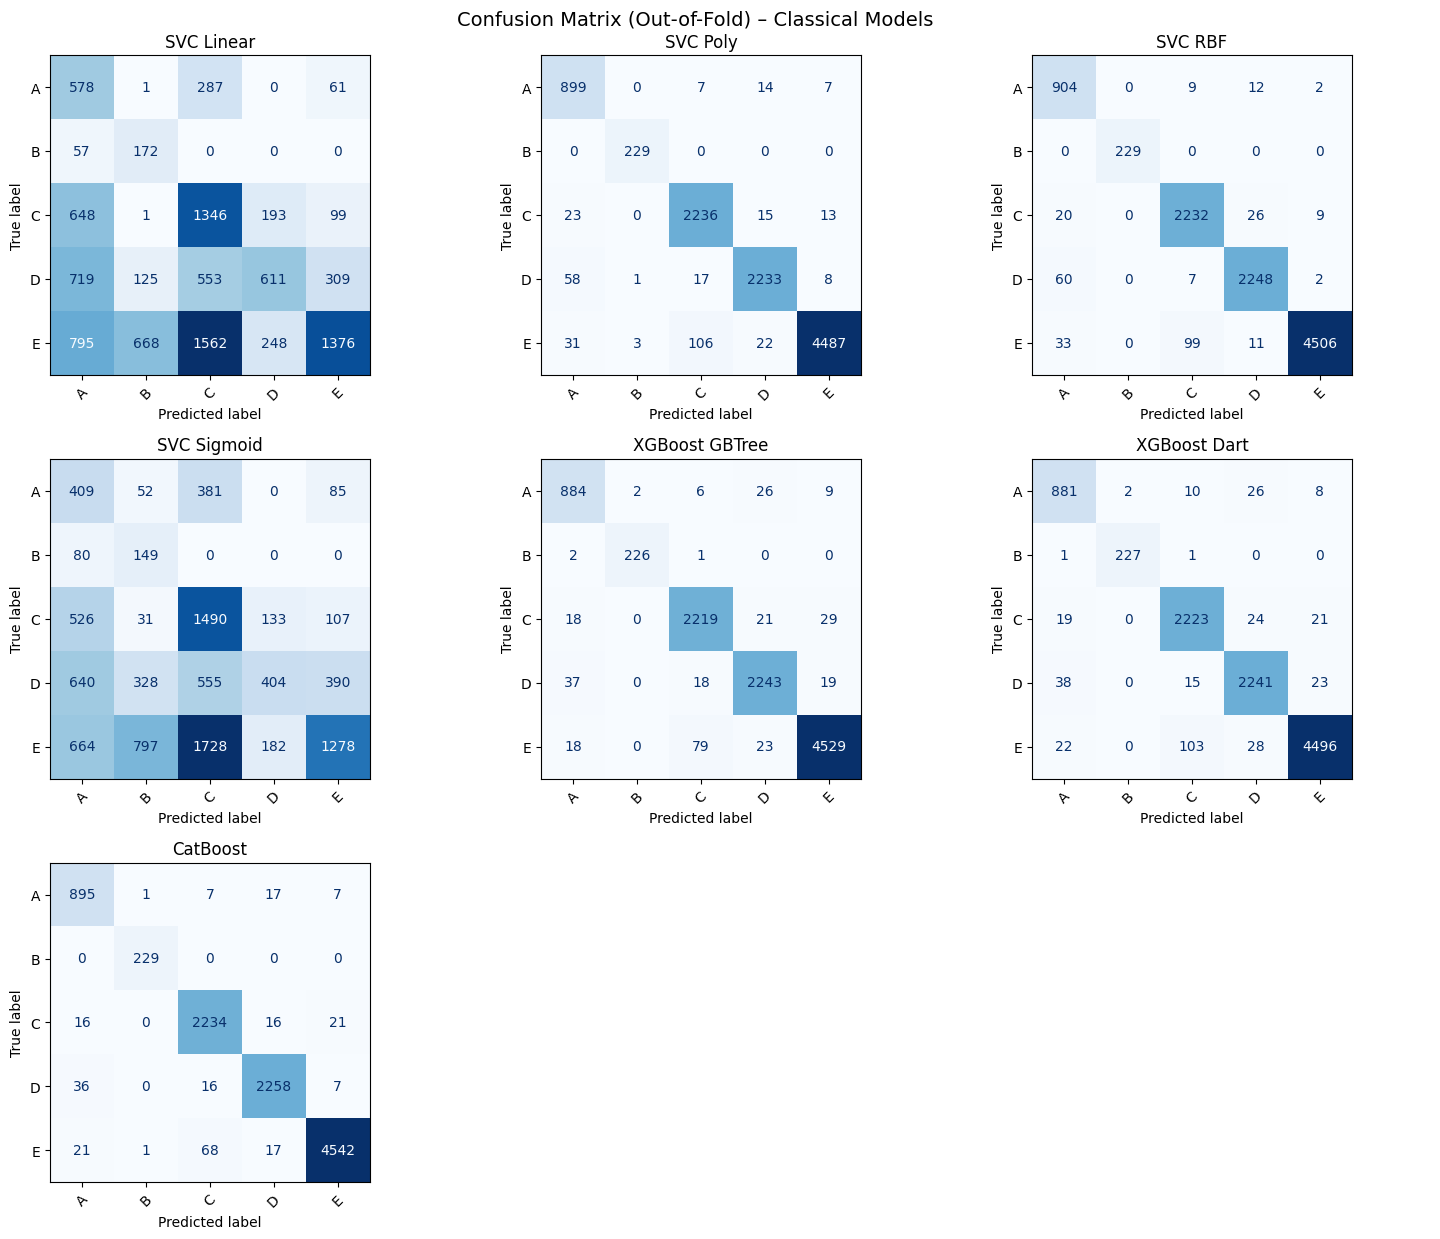

✅ Saved: ./results/confusion_matrix_classical_hpo.png
SVC Linear
              precision    recall  f1-score   support

           A       0.21      0.62      0.31       927
           B       0.18      0.75      0.29       229
           C       0.36      0.59      0.45      2287
           D       0.58      0.26      0.36      2317
           E       0.75      0.30      0.42      4649

    accuracy                           0.39     10409
   macro avg       0.41      0.50      0.37     10409
weighted avg       0.56      0.39      0.40     10409

SVC Poly
              precision    recall  f1-score   support

           A       0.89      0.97      0.93       927
           B       0.98      1.00      0.99       229
           C       0.95      0.98      0.96      2287
           D       0.98      0.96      0.97      2317
           E       0.99      0.97      0.98      4649

    accuracy                           0.97     10409
   macro avg       0.96      0.98      0.97     10409
wei

In [106]:
# ════════════════════════════════════════════════════════════
# 🔢 CONFUSION MATRIX – semua model classical (out-of-fold)
# ════════════════════════════════════════════════════════════
# Memakai prediksi out-of-fold (y_true/y_pred) yang dikumpulkan tiap model
# saat cross-validation → confusion matrix mencerminkan generalisasi, bukan
# performa di data training. Berguna untuk melihat kelas minoritas (mis. B).
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

class_names = list(label_encoder.classes_)
labels = np.arange(len(class_names))

models_cm = [r for r in all_best if "y_true" in r and "y_pred" in r]
if not models_cm:
    print("⚠️  Belum ada y_true/y_pred di all_best. Jalankan ulang sel-sel training dulu.")
else:
    n = len(models_cm)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.2 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, r in zip(axes, models_cm):
        cm = confusion_matrix(r["y_true"], r["y_pred"], labels=labels)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
        ax.set_title(r["model"])
        ax.tick_params(axis="x", rotation=45)

    for ax in axes[len(models_cm):]:
        ax.axis("off")

    fig.suptitle("Confusion Matrix (Out-of-Fold) – Classical Models", fontsize=14)
    fig.tight_layout()

    os.makedirs("./results", exist_ok=True)
    out_path = "./results/confusion_matrix_classical_hpo.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved: {out_path}")

    # ── Classification report per model (lihat performa per kelas) ──
    for r in models_cm:
        print("" + "=" * 60)
        print(r["model"])
        print("=" * 60)
        print(classification_report(
            r["y_true"], r["y_pred"],
            labels=labels, target_names=class_names, zero_division=0,
        ))


CatBoost terakhir dengan waktu eksekusi 168.8900 merupakan `loss_function="Multiclass"`, sedangkan dua sisanya adalah `loss_function="MulticlassOneVsAll"`

In [107]:
import os
os.makedirs('./results', exist_ok=True)
eval_df.to_csv('./results/eval_classical_final_hpo.csv', index=True)
print('✅ Saved: ./results/eval_classical_final_hpo.csv')

✅ Saved: ./results/eval_classical_final_hpo.csv


In [ ]:
# ════════════════════════════════════════════════════════════
# 📈 Learning Curve — semua model classical (balanced)
# ════════════════════════════════════════════════════════════
# Untuk tiap model best, hitung train vs val pada DUA metrik:
#   - Macro-F1   (makin besar makin baik)
#   - Log loss   (cross-entropy; makin kecil makin baik)
# pada beberapa ukuran training set → identifikasi overfit/underfit per model.
#
# CATATAN PERFORMA:
#   - Default pakai subsample N=2000 (stratified) supaya cepat. Naikkan
#     LC_N → len(X) untuk evaluasi penuh (jauh lebih lambat).
#   - SVC dengan training >5000 sampel akan sangat lambat (O(N²)).

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import learning_curve, StratifiedShuffleSplit, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# ── Konfigurasi ───────────────────────────────────────────────────────────────
LC_N           = len(X)                                    # subsample (stratified)
LC_TRAIN_SIZES = np.linspace(0.2, 1.0, 5)                # 5 titik kurva
LC_CV          = 5                                       # CV folds (StratifiedKFold shuffle=True, sama dengan training)
LC_STATE       = 42
LC_BASELINE    = float(np.log(len(np.unique(y))))   # log loss tebakan-acak (ambang verdict)


# ── Wrapper XGBoost agar otomatis compute sample_weight per .fit() ────────────
class XGBBalancedWrapper(ClassifierMixin, BaseEstimator):
    """XGBClassifier yang otomatis pakai class_weight='balanced' analog SVC."""
    def __init__(self, **xgb_params):
        self.xgb_params = xgb_params

    def get_params(self, deep=True):
        return dict(self.xgb_params)

    def set_params(self, **params):
        self.xgb_params.update(params)
        return self

    def fit(self, X, y, sample_weight=None):
        self.model_ = XGBClassifier(device='cuda', **self.xgb_params)
        sw = compute_sample_weight("balanced", y) if sample_weight is None else sample_weight
        self.model_.fit(X, y, sample_weight=sw)
        self.classes_ = self.model_.classes_
        return self

    def predict(self, X):
        return self.model_.predict(X)

    def predict_proba(self, X):
        return self.model_.predict_proba(X)


# ── Factory: rekonstruksi pipeline dari (model_name, best_params) ────────────
def make_classical(model_name, params):
    base = [
        ("scaler", StandardScaler()),
        ("pca",    PCA(n_components=n_optimal)),
    ]
    if   model_name == "SVC Linear":
        clf = SVC(kernel="linear",  probability=True, random_state=42,
                  decision_function_shape="ovr", class_weight='balanced', **params)
    elif model_name == "SVC Poly":
        clf = SVC(kernel="poly",    probability=True, random_state=42,
                  decision_function_shape="ovr", class_weight='balanced', **params)
    elif model_name == "SVC RBF":
        clf = SVC(kernel="rbf",     probability=True, random_state=42,
                  decision_function_shape="ovr", class_weight='balanced', **params)
    elif model_name == "SVC Sigmoid":
        clf = SVC(kernel="sigmoid", probability=True, random_state=42,
                  decision_function_shape="ovr", class_weight='balanced', **params)
    elif model_name == "XGBoost GBTree":
        clf = XGBBalancedWrapper(booster="gbtree", objective="multi:softprob",
                                 random_state=42, **params)
    elif model_name == "XGBoost Dart":
        clf = XGBBalancedWrapper(booster="dart",  objective="multi:softprob",
                                 random_state=42, **params)
    elif model_name == "CatBoost":
        clf = CatBoostClassifier(
            loss_function="MultiClassOneVsAll",
            eval_metric="Accuracy",
            verbose=0,
            random_seed=42,
            auto_class_weights="Balanced",
            task_type="GPU",
            **params,
        )
    else:
        raise ValueError(f"Unknown model_name: {model_name}")
    base.append(("clf", clf))
    return Pipeline(base)


# ── Stratified subsample untuk speed ──────────────────────────────────────────
if LC_N < len(X):
    sss = StratifiedShuffleSplit(n_splits=1, train_size=LC_N, random_state=LC_STATE)
    sub_idx, _ = next(sss.split(X, y))
    X_lc, y_lc = X.iloc[sub_idx], y[sub_idx]
else:
    X_lc, y_lc = X, y
print(f"📊 Learning curve on N={len(X_lc)} samples | CV={LC_CV} | sizes={LC_TRAIN_SIZES}")

# ── Hitung learning curve per model untuk DUA metrik (macro-F1 & log loss) ────
_lc_common = dict(
    train_sizes=LC_TRAIN_SIZES,
    cv=StratifiedKFold(n_splits=LC_CV, shuffle=True, random_state=LC_STATE),
    n_jobs=1, shuffle=True, random_state=LC_STATE, error_score='raise',
)
lc_results = []
for entry in all_best:
    name   = entry["model"]
    params = entry.get("params", {})
    print(f"\n  ▶ {name}  ({params}) ...", end=" ", flush=True)
    try:
        pipe = make_classical(name, params)
        # Macro-F1 (makin besar makin baik)
        ts, f1_tr, f1_va = learning_curve(
            pipe, X_lc, y_lc, scoring="f1_macro", **_lc_common)
        # Log loss / cross-entropy (neg_log_loss → dibalik ke positif; makin kecil makin baik)
        _,  ll_tr, ll_va = learning_curve(
            pipe, X_lc, y_lc, scoring="neg_log_loss", **_lc_common)
        ll_tr, ll_va = -ll_tr, -ll_va
        lc_results.append({
            "model":       name,
            "params":      params,
            "train_sizes": ts,
            "f1_train_mean": f1_tr.mean(axis=1), "f1_train_std": f1_tr.std(axis=1),
            "f1_val_mean":   f1_va.mean(axis=1), "f1_val_std":   f1_va.std(axis=1),
            "loss_train_mean": ll_tr.mean(axis=1), "loss_train_std": ll_tr.std(axis=1),
            "loss_val_mean":   ll_va.mean(axis=1), "loss_val_std":   ll_va.std(axis=1),
        })
        print("done")
    except Exception as e:
        print(f"FAILED — {type(e).__name__}: {e}")

os.makedirs("./results", exist_ok=True)


# ── Helper plot grid satu metrik ──────────────────────────────────────────────
def _plot_lc_grid(prefix, ylabel, lower_is_better, verdict_fn, fname, suptitle):
    n_models = len(lc_results)
    ncols    = 3
    nrows    = (n_models + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(5.5 * ncols, 4 * nrows),
                             constrained_layout=True)
    axes = np.array(axes).flatten()

    for ax, r in zip(axes, lc_results):
        ts = r["train_sizes"]
        tr_m, tr_s = r[f"{prefix}_train_mean"], r[f"{prefix}_train_std"]
        va_m, va_s = r[f"{prefix}_val_mean"],   r[f"{prefix}_val_std"]
        ax.plot(ts, tr_m, "o-", color="steelblue",  linewidth=2, label="Train")
        ax.fill_between(ts, tr_m - tr_s, tr_m + tr_s, alpha=0.2, color="steelblue")
        ax.plot(ts, va_m, "s-", color="darkorange", linewidth=2, label="Val")
        ax.fill_between(ts, va_m - va_s, va_m + va_s, alpha=0.2, color="darkorange")

        # gap diseragamkan: >0 → indikasi overfit
        gap = (va_m[-1] - tr_m[-1]) if lower_is_better else (tr_m[-1] - va_m[-1])
        verdict = verdict_fn(tr_m, va_m, gap)
        ax.set_title(f"{r['model']}\ngap={gap:+.3f}  |  {verdict}",
                     fontsize=11, fontweight="bold")
        ax.set_xlabel("Training set size")
        ax.set_ylabel(ylabel)
        if lower_is_better:
            ax.set_ylim(bottom=0)
        else:
            ax.set_ylim(0, 1.02)
        ax.grid(True, alpha=0.4)
        ax.legend(fontsize=8)

    for ax in axes[n_models:]:
        ax.set_visible(False)

    fig.suptitle(suptitle, fontsize=13, fontweight="bold")
    fig.savefig(fname, dpi=120, bbox_inches="tight")
    print(f"📊 Plot disimpan → {fname}")
    plt.show()


# ── Verdict per metrik ────────────────────────────────────────────────────────
def _verdict_loss(tr_m, va_m, gap):
    if   gap > 0.15 * LC_BASELINE:                                   return "⚠️ OVERFIT"
    elif va_m[-1] > 0.80 * LC_BASELINE:                             return "⚠️ UNDERFIT"
    elif gap < 0.05 * LC_BASELINE and va_m[-1] < 0.40 * LC_BASELINE: return "✅ Well-fit"
    else:                                                            return "🟡 Mild gap"

def _verdict_f1(tr_m, va_m, gap):
    if   gap > 0.15:                       return "⚠️ OVERFIT"
    elif va_m[-1] < 0.40:                  return "⚠️ UNDERFIT"
    elif gap < 0.05 and va_m[-1] >= 0.60:  return "✅ Well-fit"
    else:                                  return "🟡 Mild gap"


# ── Plot 1: Log loss ──────────────────────────────────────────────────────────
_plot_lc_grid(
    "loss", "log loss", lower_is_better=True, verdict_fn=_verdict_loss,
    fname="./results/learning_curve_classical_balanced_hpo_logloss.png",
    suptitle=(f"Learning Curve (Log Loss) — Classical Models (class_weight='balanced')  |  "
              f"N={len(X_lc)} | CV={LC_CV} | scoring=neg_log_loss"),
)

# ── Plot 2: Macro-F1 ──────────────────────────────────────────────────────────
_plot_lc_grid(
    "f1", "macro-F1", lower_is_better=False, verdict_fn=_verdict_f1,
    fname="./results/learning_curve_classical_balanced_hpo_f1macro.png",
    suptitle=(f"Learning Curve (Macro-F1) — Classical Models (class_weight='balanced')  |  "
              f"N={len(X_lc)} | CV={LC_CV} | scoring=f1_macro"),
)

# ── Ringkasan tekstual ────────────────────────────────────────────────────────
print("\n──── Ringkasan Log Loss (training size terbesar) ────")
print(f"{'Model':<20s} {'TrainLoss':>10s} {'ValLoss':>10s} {'Gap':>8s}")
for r in sorted(lc_results, key=lambda x: x["loss_val_mean"][-1]):
    print(f"{r['model']:<20s} {r['loss_train_mean'][-1]:>10.4f} {r['loss_val_mean'][-1]:>10.4f} "
          f"{r['loss_val_mean'][-1] - r['loss_train_mean'][-1]:>+8.4f}")

print("\n──── Ringkasan Macro-F1 (training size terbesar) ────")
print(f"{'Model':<20s} {'TrainF1':>10s} {'ValF1':>10s} {'Gap':>8s}")
for r in sorted(lc_results, key=lambda x: x["f1_val_mean"][-1], reverse=True):
    print(f"{r['model']:<20s} {r['f1_train_mean'][-1]:>10.4f} {r['f1_val_mean'][-1]:>10.4f} "
          f"{r['f1_train_mean'][-1] - r['f1_val_mean'][-1]:>+8.4f}")

📊 Learning curve on N=10409 samples | CV=5 | sizes=[0.2 0.4 0.6 0.8 1. ]

  ▶ SVC Linear  ({'C': 10, 'tol': 0.1}) ... 